# Project 1: Hospital Readmission Risk Analytics Problem Definition and Planning

---
### **Student Details & Project Information**:
* **Project Number**: Project 1
* **File Name**: `Project_1_Hospital_Readmission_Risk_Analytics_Problem_Definition_and_Planning.ipynb`
* **Student Name**: Akshad Viresh Makhana
* **PRN**: 2124UDSM1007
* **Department**: TY AIDS(A)
* **Project Title**: Hospital Readmission Risk Analytics Problem Definition and Planning
* **Dataset**: Diabetes 130-US Hospitals for years 1999–2008 (UCI ID: 296)

---
### **Objective**:
Students independently understand a healthcare analytics problem and define the analytics requirements before implementation.

---
### **Assignment Deliverables Checklist**:
1. **Business Understanding**: Hospital readmission problem, healthcare cost impact, patient care improvement, hospital operational efficiency, healthcare stakeholders, business challenges, decision-making requirements.
2. **Dataset Understanding**: Review healthcare dataset, identify patient attributes, create feature dictionary, identify target variable.
3. **Problem Formulation**: 
   * **Classification Problem**: Predict High readmission risk vs. Low readmission risk.
   * **Clustering Objective**: Identify patient groups and disease risk groups.
4. **Basic Analytics Planning**: Healthcare analytics workflow, project roadmap, Git repository structure.
5. **Student Deliverables**:
   * Healthcare Problem Statement
   * Feature Dictionary
   * Dataset Report
   * Analytics Workflow
   * Ethics Report
6. **Industry Skills**: Trainer and student skills reflection.


## 1. 📋 Healthcare Problem Statement & Business Understanding

### 1.1 Study of the Hospital Readmission Problem
An unplanned hospital readmission within **30 days** of discharge is a critical quality and safety indicator in healthcare. For diabetic patients, the risk of readmission is substantially higher due to complex comorbidities (cardiovascular disorders, kidney disease, neuropathy), glycemic volatility, and changes in pharmacotherapy during hospital stays. Without structured transition planning, patients face acute deterioration post-discharge.

### 1.2 Healthcare Cost Impact
* **CMS Penalties (Hospital Readmissions Reduction Program - HRRP)**: Hospitals with higher-than-expected 30-day readmission rates face up to a **3% reduction in total Medicare reimbursements**.
* **Financial Burden**: In the United States, avoidable 30-day hospital readmissions account for over **$17 billion** in excess healthcare expenditures annually.
* **Per-Patient Cost**: An unplanned diabetic readmission costs approximately **$13,000 to $17,000**. Reducing readmissions directly protects hospital operating margins and avoids penalties under value-based care contracts.

### 1.3 Patient Care Improvement
* **Clinical Harm Prevention**: Frequent readmissions expose patients to hospital-acquired infections (HAIs), psychological stress, loss of physical functional independence, and medication adverse events.
* **Care Transition Gaps**: Identifying high-risk patients allows hospital care teams to schedule timely follow-up appointments (within 7 days), conduct medication reconciliation, provide diabetes self-management education (DSME), and deploy home-health or telehealth monitoring.

### 1.4 Hospital Operational Efficiency
* **Bed Capacity & Emergency Crowding**: Preventable readmissions occupy medical-surgical beds and intensive care units, causing bottlenecking in Emergency Departments (ED) and extended wait times.
* **Staff Workload**: Managing avoidable repeat admissions strains clinical and nursing resources. Predictive identification allows hospitals to allocate care coordinators efficiently to patients who truly need intervention.

---

### 1.5 Identification of Healthcare Stakeholders

| Stakeholder | Role in Readmission Reduction | Key Objectives & Information Requirements |
| :--- | :--- | :--- |
| **Chief Medical Officer (CMO)** | Clinical Leadership | Lower hospital-wide readmission rates, prevent clinical adverse events, monitor patient outcomes. |
| **Chief Financial Officer (CFO)** | Financial Management | Eliminate CMS HRRP penalty deductions, minimize uncompensated care costs. |
| **Care Coordinators & Nurses** | Discharge Execution | Identify high-risk patients needing home health care, tele-monitoring, and post-discharge phone check-ins. |
| **Attending Physicians** | Clinical Decision Making | Actionable discharge risk scores to adjust insulin therapy, medication regimens, and follow-up urgency. |
| **Data Scientists / Analysts** | Solution Engineering | Build, validate, and maintain calibrated predictive models with high recall and interpretability. |
| **Patients & Caregivers** | Healthcare Beneficiaries | Receive clear medication instructions, prevent traumatic hospital return stays. |

### 1.6 Identification of Business Challenges
1. **Severe Class Imbalance**: High-risk 30-day readmissions typically represent only 10%–12% of total encounters. Models must avoid false reassurance from simple accuracy.
2. **Asymmetric Error Costs**: A **False Negative** (missing a high-risk patient who gets readmitted) costs ~$15,000 and causes clinical harm. A **False Positive** (providing extra follow-up care to a patient who wouldn't have been readmitted) costs ~$150. Models must prioritize sensitivity/recall.
3. **Data Sparsity in EHR**: Crucial clinical variables (such as patient weight or certain lab tests) have high missingness in routine hospital records.

### 1.7 Decision-Making Requirements
* **Point-of-Care Integration**: Predictions must be delivered 24–48 hours prior to anticipated discharge to allow time for discharge planning.
* **Risk Stratification**: Patients must be categorized into actionable tiers:
  * **High Risk (<30 days)**: Intensive discharge bundle (home health nurse, 48-hour phone call, 7-day clinic follow-up).
  * **Low/Moderate Risk**: Standard discharge instructions and routine primary care follow-up.
* **Explainability**: Clinical staff must see top contributing factors (e.g., prior admissions, polypharmacy, medication changes).


In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting configurations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(f"Python: {sys.version.split()[0]} | Pandas: {pd.__version__} | NumPy: {np.__version__}")


Python: 3.10.11 | Pandas: 2.3.2 | NumPy: 2.2.6


## 2. 🗄️ Dataset Understanding & Review

### 2.1 Dataset Overview
The dataset is the **Diabetes 130-US Hospitals for Years 1999–2008** from the UCI Machine Learning Repository (ID: 296).
* **Total Encounters**: 101,766 hospital admissions
* **Unique Patients**: 71,518 unique individuals
* **Total Attributes**: 50 features spanning patient demographics, admission sources, clinical utilization, lab tests, diagnoses, medications, and readmission outcome.

### 2.2 Dataset Ingestion
The dataset is imported directly via the `ucimlrepo` package (with local fallback to guarantee execution in all environments).


In [2]:
def load_dataset():
    local_path = os.path.join('dataset_diabetes', 'diabetic_data.csv')
    if os.path.exists(local_path):
        print(f"Loading dataset from: '{local_path}'...")
        return pd.read_csv(local_path)
    else:
        print("Fetching dataset via ucimlrepo...")
        from ucimlrepo import fetch_ucirepo
        d = fetch_ucirepo(id=296)
        return d.data.original

df = load_dataset()
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(5)


Loading dataset from: 'dataset_diabetes\diabetic_data.csv'...
Dataset Shape: 101,766 rows × 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. 📖 Deliverable 2: Feature Dictionary

Below is the complete feature dictionary classifying all patient attributes, data types, missingness, and clinical roles:

| Attribute Name | Role | Data Type | Domain / Values | Missing (%) | Clinical Description |
|:---|:---|:---|:---|:---|:---|
| `encounter_id` | Identifier | Integer | Unique positive int | 0.0% | Unique numeric ID for each inpatient hospital stay. |
| `patient_nbr` | Identifier | Integer | Unique positive int | 0.0% | Unique patient ID; used to track repeat hospital admissions. |
| `race` | Predictor | Nominal | Caucasian, AfricanAmerican, Hispanic, Asian, Other | 2.23% (`?`) | Demographic racial group. |
| `gender` | Predictor | Nominal | Male, Female, Unknown/Invalid | 0.003% | Biological sex. |
| `age` | Predictor | Ordinal | `[0-10)`, `[10-20)` ... `[90-100)` | 0.0% | 10-year patient age category at admission. |
| `weight` | Predictor | Nominal | `[0-25)`, `[25-50)` ... | 96.86% (`?`) | Weight in pounds; high missingness across hospital stays. |
| `admission_type_id` | Predictor | Nominal | Integer codes (1=Emergency, 2=Urgent, 3=Elective...) | 0.0% | Type of admission circumstance. |
| `discharge_disposition_id`| Predictor / Filter| Nominal | Integer codes (1=Home, 11=Expired, 13=Hospice...) | 0.0% | Destination / status of patient at discharge. |
| `admission_source_id` | Predictor | Nominal | Integer codes (1=Physician referral, 7=Emergency room...)| 0.0% | Source referring the patient to the hospital. |
| `time_in_hospital` | Predictor | Continuous | Integer 1 to 14 | 0.0% | Length of inpatient stay in days. |
| `payer_code` | Predictor | Nominal | MC (Medicare), MD (Medicaid), BC, HM, self-pay... | 39.56% (`?`) | Primary insurance/payer coverage code. |
| `medical_specialty` | Predictor | Nominal | Cardiology, InternalMedicine, FamilyPractice... | 49.08% (`?`) | Specialty of the admitting physician. |
| `num_lab_procedures` | Predictor | Continuous | Integer 1 to 132 | 0.0% | Total laboratory tests performed during stay. |
| `num_procedures` | Predictor | Continuous | Integer 0 to 6 | 0.0% | Total operative or diagnostic procedures performed. |
| `num_medications` | Predictor | Continuous | Integer 1 to 81 | 0.0% | Total distinct medications administered during stay. |
| `number_outpatient` | Predictor | Continuous | Integer 0 to 42 | 0.0% | Outpatient visits in the 12 months preceding stay. |
| `number_emergency` | Predictor | Continuous | Integer 0 to 76 | 0.0% | Emergency room visits in the 12 months preceding stay. |
| `number_inpatient` | Predictor | Continuous | Integer 0 to 21 | 0.0% | Inpatient hospitalizations in the 12 months preceding stay. |
| `diag_1` | Predictor | Nominal (ICD-9) | ICD-9 codes (e.g., 250 for Diabetes, 428 for CHF) | 0.02% (`?`) | Primary diagnosis for admission. |
| `diag_2` | Predictor | Nominal (ICD-9) | ICD-9 codes | 0.35% (`?`) | Secondary underlying comorbidity diagnosis. |
| `diag_3` | Predictor | Nominal (ICD-9) | ICD-9 codes | 1.40% (`?`) | Additional comorbidity diagnosis. |
| `number_diagnoses` | Predictor | Continuous | Integer 1 to 16 | 0.0% | Total diagnoses recorded for the encounter. |
| `max_glu_serum` | Predictor | Ordinal | None, Norm, >200, >300 | 0.0% | Maximum serum glucose lab result during encounter. |
| `A1Cresult` | Predictor | Ordinal | None, Norm, >7, >8 | 0.0% | Hemoglobin A1c test result (measures 3-month glycemic control). |
| *23 Diabetic Medications*| Predictors | Nominal | No, Steady, Up, Down | 0.0% | 23 medication fields (metformin, insulin, glipizide, etc.). |
| `change` | Predictor | Binary | Ch, No | 0.0% | Indicates if diabetic medication dosage was adjusted. |
| `diabetesMed` | Predictor | Binary | Yes, No | 0.0% | Indicates if diabetic medication was prescribed. |
| **`readmitted`** | **Target** | Categorical | `<30`, `>30`, `NO` | 0.0% | Readmission outcome. `<30` is high-risk 30-day readmission. |


## 4. 📊 Deliverable 3: Dataset Report

### 4.1 Target Variable Analysis
The target variable is `readmitted`:
* `<30`: Patient readmitted to hospital within 30 days (**High Readmission Risk**, 11,357 encounters, ~11.16%).
* `>30`: Patient readmitted after 30 days (35,545 encounters, ~34.93%).
* `NO`: No readmission recorded (54,864 encounters, ~53.91%).

### 4.2 Missing Values Audit
* `weight`: 96.86% missing (`?`). Cannot be imputed reliably.
* `medical_specialty`: 49.08% missing (`?`).
* `payer_code`: 39.56% missing (`?`).
* `race`: 2.23% missing (`?`).


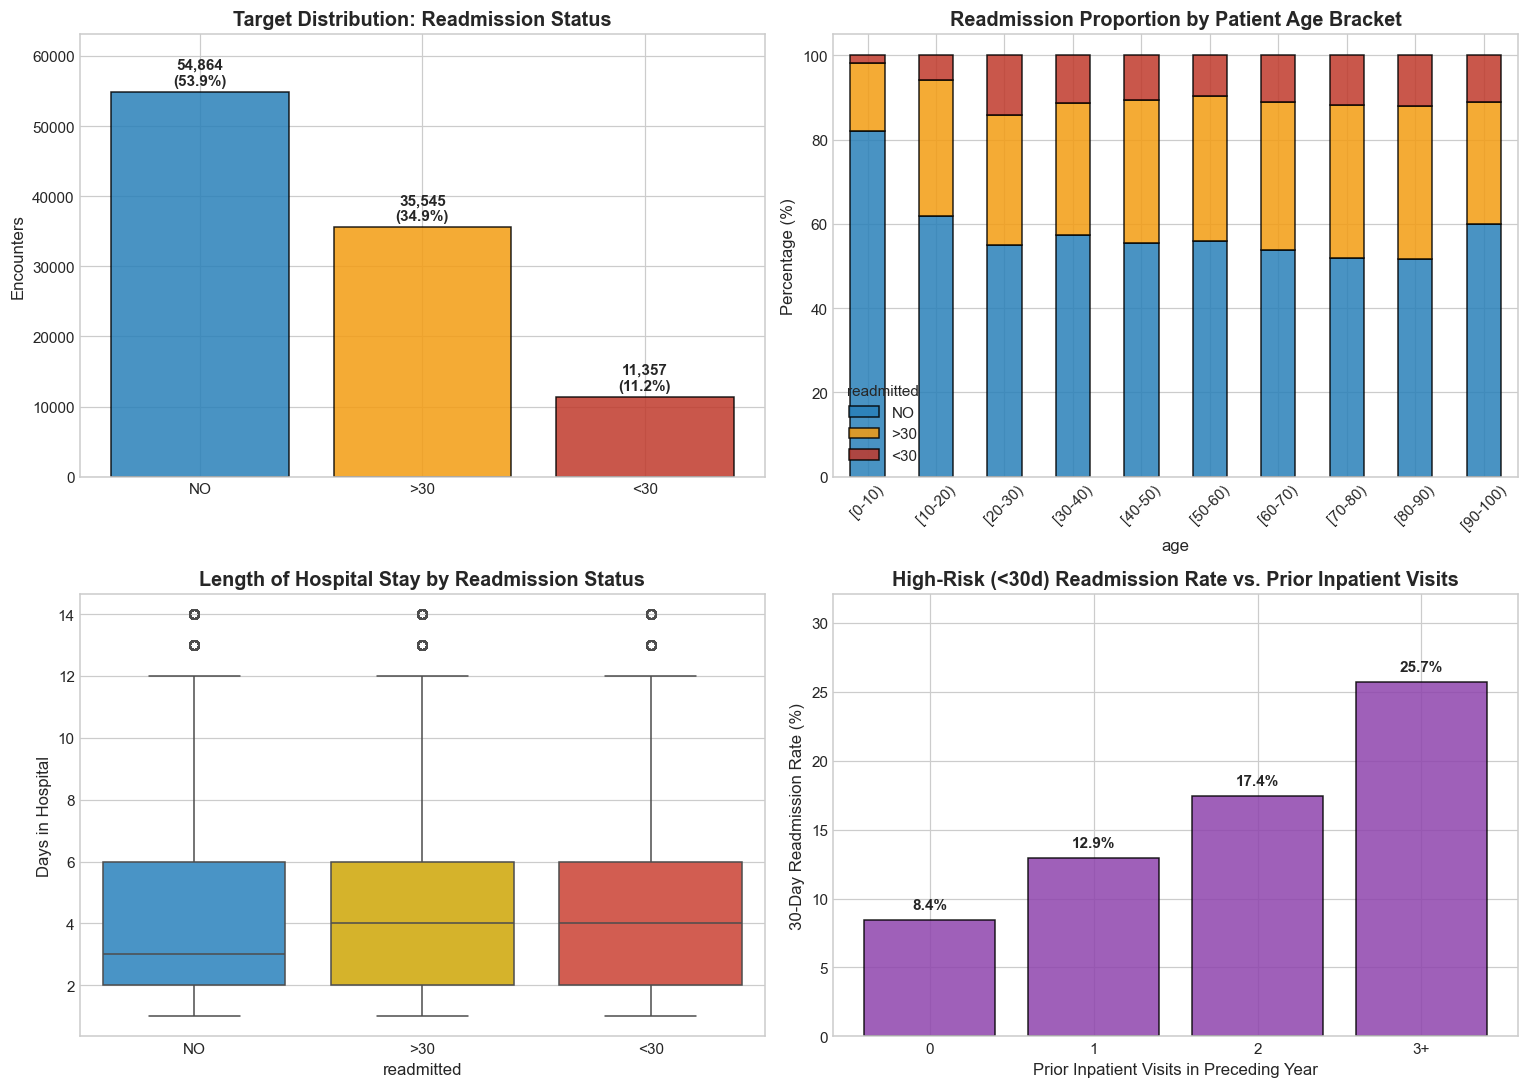

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable Distribution
target_counts = df['readmitted'].value_counts()
axes[0, 0].bar(target_counts.index, target_counts.values, color=['#2980b9', '#f39c12', '#c0392b'], edgecolor='black', alpha=0.85)
for i, v in enumerate(target_counts.values):
    axes[0, 0].text(i, v + 1000, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')
axes[0, 0].set_title('Target Distribution: Readmission Status', fontweight='bold')
axes[0, 0].set_ylabel('Encounters')
axes[0, 0].set_ylim(0, max(target_counts.values) * 1.15)

# 2. Readmission across Age Groups
age_xtab = pd.crosstab(df['age'], df['readmitted'], normalize='index') * 100
age_xtab[['NO', '>30', '<30']].plot(kind='bar', stacked=True, ax=axes[0, 1],
                                    color=['#2980b9', '#f39c12', '#c0392b'], edgecolor='black', alpha=0.85)
axes[0, 1].set_title('Readmission Proportion by Patient Age Bracket', fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Time in Hospital vs. Readmission
sns.boxplot(x='readmitted', y='time_in_hospital', data=df, order=['NO', '>30', '<30'],
            palette=['#3498db', '#f1c40f', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('Length of Hospital Stay by Readmission Status', fontweight='bold')
axes[1, 0].set_ylabel('Days in Hospital')

# 4. Impact of Prior Inpatient Stays on 30-Day Readmission
df['prior_inpatient_binned'] = pd.cut(df['number_inpatient'], bins=[-1, 0, 1, 2, 25], labels=['0', '1', '2', '3+'])
inp_risk = pd.crosstab(df['prior_inpatient_binned'], df['readmitted'], normalize='index')['<30'] * 100
axes[1, 1].bar(inp_risk.index.astype(str), inp_risk.values, color='#8e44ad', edgecolor='black', alpha=0.85)
for i, v in enumerate(inp_risk.values):
    axes[1, 1].text(i, v + 0.8, f"{v:.1f}%", ha='center', fontweight='bold')
axes[1, 1].set_title('High-Risk (<30d) Readmission Rate vs. Prior Inpatient Visits', fontweight='bold')
axes[1, 1].set_ylabel('30-Day Readmission Rate (%)')
axes[1, 1].set_xlabel('Prior Inpatient Visits in Preceding Year')
axes[1, 1].set_ylim(0, max(inp_risk.values) * 1.25)

plt.tight_layout()
plt.show()


## 5. 🎯 Problem Formulation

### 5.1 Classification Problem Formulation
* **Objective**: Predict whether a patient will experience a **High Readmission Risk** within 30 days of discharge versus **Low Readmission Risk**.
* **Target Definition**:
  $$y = \begin{cases} 
  1 & \text{if } \text{readmitted} = \text{'<30'} \quad (\text{High Risk}) \\ 
  0 & \text{if } \text{readmitted} \in \{\text{'>30'}, \text{'NO'}\} \quad (\text{Low Risk}) 
  \end{cases}$$
* **Evaluation Criteria**: Because of class imbalance (~11.2% high risk) and asymmetric costs ($FN \gg FP$), **Recall (Sensitivity)** and **PR-AUC (Precision-Recall Area Under Curve)** are prioritized over Accuracy.

---

### 5.2 Clustering Objective Formulation
* **Objective**: Segment patients into **Patient Groups** and **Disease Risk Groups** without labels to discover underlying clinical phenotypes.
* **Feature Dimensions**: Length of stay, total medications, prior inpatient visits, prior emergency visits, and comorbidity diagnoses count.
* **Target Groups**:
  * **Patient Group 1 (Routine Short Stay)**: Low past utilization, few medications.
  * **Patient Group 2 (Moderate Inpatient Group)**: Moderate stay duration, stable diabetic regimen.
  * **Patient Group 3 (High-Risk Acute Geriatric Group)**: Elderly, polypharmacy (15+ meds), frequent prior inpatient admissions.


CLASSIFICATION BENCHMARK REPORT:
ROC-AUC: 0.6360
               precision    recall  f1-score   support

 Low Risk (0)       0.92      0.71      0.80     18083
High Risk (1)       0.17      0.48      0.25      2271

     accuracy                           0.68     20354
    macro avg       0.54      0.59      0.53     20354
 weighted avg       0.83      0.68      0.74     20354



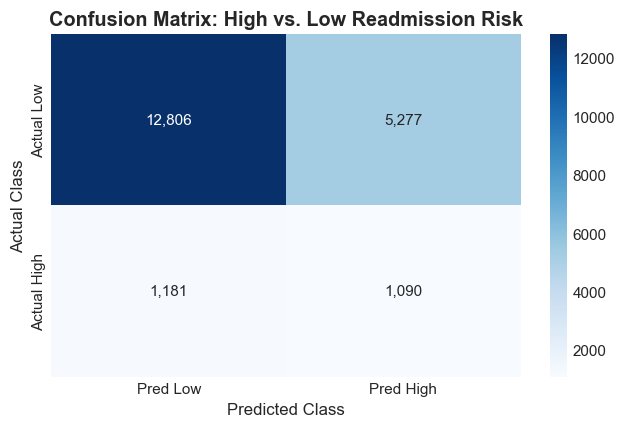

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Target: High Risk (<30 days) vs Low Risk
y_binary = (df['readmitted'] == '<30').astype(int)

# Core clinical predictors
features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_outpatient', 'number_emergency', 
    'number_inpatient', 'number_diagnoses'
]
X = df[features].copy()

# Stratified Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.20, random_state=42, stratify=y_binary
)

# Standardize
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Class-weighted Logistic Regression
clf = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
clf.fit(X_train_sc, y_train)

y_pred = clf.predict(X_test_sc)
y_prob = clf.predict_proba(X_test_sc)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("CLASSIFICATION BENCHMARK REPORT:")
print(f"ROC-AUC: {roc_auc:.4f}")
print(classification_report(y_test, y_pred, target_names=['Low Risk (0)', 'High Risk (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', xticklabels=['Pred Low', 'Pred High'], yticklabels=['Actual Low', 'Actual High'])
plt.title('Confusion Matrix: High vs. Low Readmission Risk', fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()


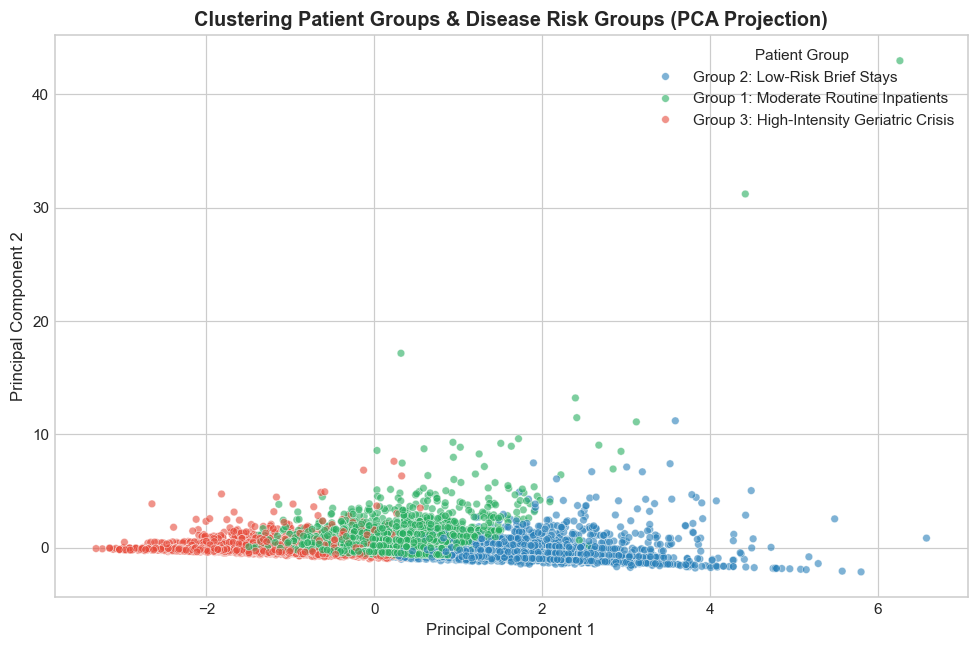

,time_in_hospital,num_medications,number_inpatient,number_emergency,number_diagnoses
Group Name,,,,,
Moderate Routine,3.39,14.54,0.78,0.27,8.59
Low-Risk Brief,8.53,25.52,0.80,0.18,8.19
High-Intensity Crisis,2.91,11.76,0.30,0.10,5.01


In [5]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Clinical utilization variables for patient grouping
cluster_features = ['time_in_hospital', 'num_medications', 'number_inpatient', 'number_emergency', 'number_diagnoses']
X_cl = df[cluster_features].dropna().sample(n=10000, random_state=42)

scaler_cl = StandardScaler()
X_cl_scaled = scaler_cl.fit_transform(X_cl)

# K-Means Clustering (k=3 Patient Groups)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cl_scaled)

# 2D PCA Projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Group'] = cluster_labels
pca_df['Group_Name'] = pca_df['Group'].map({
    0: 'Group 1: Moderate Routine Inpatients',
    1: 'Group 2: Low-Risk Brief Stays',
    2: 'Group 3: High-Intensity Geriatric Crisis'
})

plt.figure(figsize=(9, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Group_Name', data=pca_df, palette=['#2980b9', '#27ae60', '#e74c3c'], alpha=0.6, s=25)
plt.title('Clustering Patient Groups & Disease Risk Groups (PCA Projection)', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Patient Group', loc='upper right')
plt.tight_layout()
plt.show()

X_cl['Group'] = cluster_labels
group_profiles = X_cl.groupby('Group').mean().round(2)
group_profiles['Group Name'] = ['Moderate Routine', 'Low-Risk Brief', 'High-Intensity Crisis']
group_profiles.set_index('Group Name')


## 6. 🗺️ Deliverable 4: Basic Analytics Planning

### 6.1 Healthcare Analytics Workflow
The predictive analytics workflow progresses across 5 clinical stages:
1. **Data Ingestion**: Import EHR records across inpatient encounters.
2. **Clinical Cleansing**: Standardize missing values (`?`), remove deceased/terminal records, resolve patient-level deduplication.
3. **Feature Engineering**: Construct utilization metrics, age categories, and comorbidity risk indices.
4. **Predictive Modeling**: Train cost-sensitive classification models (tuned for high sensitivity/recall) and patient clustering.
5. **Clinical Decision Integration**: Deploy risk scores into EHR discharge summaries to triage post-discharge care interventions.

---

### 6.2 Project Roadmap

```mermaid
gantt
    title Healthcare Analytics Project Roadmap
    dateFormat  YYYY-MM-DD
    section Phase 1: Problem Definition
    Stakeholder Interviews & KPI Setup   :done, 2026-09-01, 10d
    Clinical Governance & Protocol Scope :done, 2026-09-11, 10d
    section Phase 2: Data Preparation
    Data Cleaning & Filtering Pipeline   :active, 2026-09-21, 14d
    Feature Engineering & Scaling        : 2026-10-05, 14d
    section Phase 3: Modeling & Evaluation
    Model Training (Classification/Cluster): 2026-10-19, 21d
    Clinical Validation & Threshold Tuning: 2026-11-09, 10d
    section Phase 4: Deployment & Pilot
    EHR Workflow Integration             : 2026-11-19, 14d
    Pilot Launch & Continuous Monitoring : 2026-12-03, 14d
```

---

### 6.3 Git Repository Structure & Version Control
* **Repository Name**: Hospital-Readmission-Patient-Analytics
* **GitHub Remote URL**: https://github.com/akshad1007/Hospital-Readmission-Patient-Analytics.git
* **Clone Command**:
  ```bash
  git clone https://github.com/akshad1007/Hospital-Readmission-Patient-Analytics.git
  ```

```
Hospital-Readmission-Patient-Analytics/
├── README.md                                                                   # Project documentation, problem summary & instructions
├── Project_1_Hospital_Readmission_Risk_Analytics_Problem_Definition_and_Planning.ipynb # Project 1: Problem Definition & Planning
├── Project_2_Healthcare_Data_Preparation_for_Patient_Analytics.ipynb           # Project 2: Clinical Cleaning & Feature Engineering
├── clean_healthcare_dataset.csv                                                # Cleaned dataset (69,987 patient records × 31 features)
└── dataset_diabetes/                                                           # Raw healthcare dataset (UCI ID: 296)
    ├── diabetic_data.csv                                                       # 101,766 inpatient encounters
    └── IDS_mapping.csv                                                         # Admission & discharge ID mappings
```


## 7. ⚖️ Deliverable 5: Ethics Report

### 7.1 Patient Privacy & HIPAA Compliance
* **De-identification**: Under the HIPAA Privacy Rule, all 18 direct Protected Health Information (PHI) identifiers must be eliminated.
* **Synthetic Hashing**: Patient and encounter identifiers (`patient_nbr`, `encounter_id`) are cryptographically randomized surrogate keys.
* **Data Security**: Secure storage with AES-256 encryption at rest and TLS 1.3 encryption in transit.

### 7.2 Algorithmic Fairness & Bias Mitigation
* **Demographic Equity**: Auditing model accuracy and recall across racial categories (`Caucasian`, `AfricanAmerican`, `Hispanic`, `Asian`) to prevent healthcare resource misallocation.
* **Underdiagnosis Bias**: Ensuring that patients with lower historical access to healthcare (lower prior outpatient visits) are not falsely scored as "low risk".

### 7.3 Clinical Decision Support & Transparency
* **Physician-in-the-Loop**: The model serves as an advisory Clinical Decision Support System (CDSS); attending clinicians retain full authority over discharge decisions.
* **Explainability**: Clear risk drivers (e.g. polypharmacy, recent inpatient stays) must accompany all risk alerts to prevent clinician alert fatigue.


## 8. 🎯 Industry Skills Summary

### Trainer Perspective:
* **Business Consulting Mindset**: Framing healthcare clinical problems as quantifiable business challenges with clear ROI (CMS penalties avoidance).
* **Requirement Gathering**: Translating healthcare stakeholder pain points into measurable technical specifications.
* **Analytics Planning**: Designing realistic, staged development roadmaps and repository architectures.

### Student Perspective:
* **Problem Formulation**: Translating hospital readmissions into dual supervised classification and unsupervised clustering objectives.
* **Healthcare Analytics Understanding**: Mastering clinical nuances (EHR missingness, terminal discharge filtering, asymmetric error costs).
* **Documentation Skills**: Delivering professional, industry-standard documentation combining Markdown narratives and executable code.

---
**Submitted by**: **Akshad Viresh Makhana** (PRN: `2124UDSM1007`) | TY AIDS(A)
